In [2]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import io
from sklearn.model_selection import train_test_split
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from collections import Counter, defaultdict
import random

In [3]:
# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Blob file names
BLOB_NAMES = {
    "embeddings": "embeddings_checkpoint-592000.npy",
    "labels": "labels_checkpoint-592000.npy"
}

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Function to download and load .npy files
def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))

# Load embeddings and labels
X = load_npy_from_azure(BLOB_NAMES["embeddings"])  # Features (embeddings)
y = load_npy_from_azure(BLOB_NAMES["labels"])      # Labels

# Print shape to verify
print("Feature matrix shape:", X.shape)  # (num_samples, embedding_dim)
print("Labels shape:", y.shape)          # (num_samples,)

# Define words and their labels
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]

word_labels = dict(words_labels)
print("Word labels:", word_labels)

# Create word_to_indices mapping
word_to_indices = {}
current_idx = 0

for word, label in words_labels:
    # Count embeddings for this word
    count = 0
    start_idx = current_idx
    
    while current_idx < len(y) and y[current_idx] == label:
        count += 1
        current_idx += 1
    
    # Store indices for this word
    if count > 0:
        word_to_indices[word] = list(range(start_idx, start_idx + count))
    else:
        word_to_indices[word] = []

Feature matrix shape: (117652, 768)
Labels shape: (117652,)
Word labels: {'man': 1, 'vrouw': 0, 'broer': 1, 'zus': 0, 'zoon': 1, 'dochter': 0, 'neef': 1, 'nicht': 0, 'vader': 1, 'moeder': 0, 'opa': 1, 'oma': 0, 'kleinzoon': 1, 'kleindochter': 0, 'grootvader': 1, 'grootmoeder': 0, 'oom': 1, 'tante': 0, 'papa': 1, 'mama': 0, 'jongen': 1, 'meisje': 0, 'jongetje': 1, 'meid': 0, 'schoonvader': 1, 'schoonmoeder': 0, 'schoonzoon': 1, 'schoondochter': 0, 'stiefvader': 1, 'stiefmoeder': 0, 'stiefzoon': 1, 'stiefdochter': 0, 'peetvader': 1, 'peetmoeder': 0, 'bruidegom': 1, 'bruid': 0, 'meneer': 1, 'mevrouw': 0, 'mijnheer': 1, 'heer': 1, 'dame': 0, 'kerel': 1, 'mister': 1, 'miss': 0, 'mr': 1, 'ms': 0, 'prins': 1, 'prinses': 0, 'koning': 1, 'koningin': 0, 'lord': 1, 'lady': 0, 'baron': 1, 'barones': 0, 'hertog': 1, 'hertogin': 0, 'monnik': 1, 'non': 0, 'hijzelf': 1, 'zijzelf': 0, 'mannelijk': 1, 'vrouwelijk': 0, 'gentleman': 1, 'gozer': 1, 'wijf': 0}


### Verification of Embedding Assignment Consistency

To verify a subtle issue in the logic that maps words to their corresponding embeddings, we inspected two things:

1. The number of embeddings assigned per word:
   ```python
   for word, indices in word_to_indices.items():
       print(f"{word}: {len(indices)} embeddings")
    ```

2. The sequence and grouping of gender labels:

   ```python
   run_lengths = count_consecutive_runs(y.tolist())
   print("Consecutive label counts:", run_lengths)
   ```

This comparison helped us identify a minimal but important mistake: when two consecutive words share the same gender label (e.g., `"mijnheer"` and `"heer"` both labeled `1`), all embeddings from the contiguous label block are attributed to the first word (`"mijnheer"`), leaving the second word (`"heer"`) with none. This happens because the assignment logic assumes a one-to-one mapping between label runs and words, without accounting for repeated labels.

Fortunately, this issue does not affect the integrity of the SVM model. Since we are using only the gender label (`0` for female, `1` for male) to train the SVM, not the individual words, the classification task remains unaffected. Still, this analysis was useful to confirm that while the word-to-embedding mapping may be imperfect, the label-to-embedding alignment remains valid for training purposes.

In [ ]:
for word, indices in word_to_indices.items():
    print(f"{word}: {len(indices)} embeddings")

man: 19143 embeddings
vrouw: 15604 embeddings
broer: 2588 embeddings
zus: 1512 embeddings
zoon: 9062 embeddings
dochter: 4349 embeddings
neef: 474 embeddings
nicht: 373 embeddings
vader: 11701 embeddings
moeder: 12732 embeddings
opa: 454 embeddings
oma: 688 embeddings
kleinzoon: 230 embeddings
kleindochter: 264 embeddings
grootvader: 706 embeddings
grootmoeder: 525 embeddings
oom: 1354 embeddings
tante: 1358 embeddings
papa: 2140 embeddings
mama: 1604 embeddings
jongen: 3108 embeddings
meisje: 4575 embeddings
jongetje: 384 embeddings
meid: 428 embeddings
schoonvader: 174 embeddings
schoonmoeder: 279 embeddings
schoonzoon: 149 embeddings
schoondochter: 129 embeddings
stiefvader: 61 embeddings
stiefmoeder: 44 embeddings
stiefzoon: 10 embeddings
stiefdochter: 6 embeddings
peetvader: 14 embeddings
peetmoeder: 3 embeddings
bruidegom: 189 embeddings
bruid: 260 embeddings
meneer: 1941 embeddings
mevrouw: 1779 embeddings
mijnheer: 2147 embeddings
heer: 0 embeddings
dame: 692 embeddings
kerel: 

In [ ]:
import numpy as np

# Print raw label list
print("Labels:", y.tolist())

# Function to count consecutive runs
def count_consecutive_runs(labels):
    if len(labels) == 0:
        return []

    counts = []
    current = labels[0]
    count = 1

    for label in labels[1:]:
        if label == current:
            count += 1
        else:
            counts.append(count)
            current = label
            count = 1
    counts.append(count)
    return counts

# Run it on the labels
run_lengths = count_consecutive_runs(y.tolist())
print("Consecutive label counts:", run_lengths)


Labels: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

In [ ]:
# Group = word name for each embedding
groups_raw = []
X_raw = []
y_raw = []

# Flatten X and y using all original embeddings
for word, indices in word_to_indices.items():
    for idx in indices:
        groups_raw.append(word)
        X_raw.append(X[idx])
        y_raw.append(word_labels[word])

# Downsample high-frequency words
def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)

word_counts = Counter(groups)
print("Word counts after downsampling:")
for word, count in word_counts.items():
    print(f"{word}: {count}")

# GroupKFold
gkf = GroupKFold(n_splits=5)
accuracies = []

print("Running Group-Aware Cross-Validation (5-fold) with full embeddings:\n")

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups)):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y_full[train_idx], y_full[test_idx]
    test_groups = groups[test_idx]

    label_counts = Counter(y_test)
    print(f"Fold {fold_idx + 1} label distribution:", label_counts)

    model = SVC(kernel='linear', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Fold {fold_idx + 1} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"]))

print("="*50)
print(f"\nAverage accuracy across folds (full embeddings): {np.mean(accuracies):.4f}")

# Dimension-wise analysis
embedding_dim = X_full.shape[1]
dim_accuracies = []

print("\nRunning dimension-wise Group-Aware Cross-Validation:\n")

for d in range(embedding_dim):
    print(f"--- Dimension {d} ---")
    X_dim = X_full[:, d].reshape(-1, 1)
    dim_fold_accuracies = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_dim, y_full, groups)):
        X_train, X_test = X_dim[train_idx], X_dim[test_idx]
        y_train, y_test = y_full[train_idx], y_full[test_idx]

        model = SVC(kernel='linear', random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        dim_fold_accuracies.append(acc)

    avg_acc = np.mean(dim_fold_accuracies)
    dim_accuracies.append(avg_acc)
    print(f"Average accuracy for dimension {d}: {avg_acc:.4f}\n")

# Sort and show best/worst performing dimensions
best_dims = np.argsort(dim_accuracies)[::-1]
print("="*50)
print("Top 5 dimensions:")
for i in range(5):
    dim = best_dims[i]
    print(f"Dim {dim}: Accuracy = {dim_accuracies[dim]:.4f}")

print("\nBottom 5 dimensions:")
for i in range(1, 6):
    dim = best_dims[-i]
    print(f"Dim {dim}: Accuracy = {dim_accuracies[dim]:.4f}")


Word counts after downsampling:
man: 200
vrouw: 200
broer: 200
zus: 200
zoon: 200
dochter: 200
neef: 200
nicht: 200
vader: 200
moeder: 200
opa: 200
oma: 200
kleinzoon: 200
kleindochter: 200
grootvader: 200
grootmoeder: 200
oom: 200
tante: 200
papa: 200
mama: 200
jongen: 200
meisje: 200
jongetje: 200
meid: 200
schoonvader: 174
schoonmoeder: 200
schoonzoon: 149
schoondochter: 129
stiefvader: 61
stiefmoeder: 44
stiefzoon: 10
stiefdochter: 6
peetvader: 14
peetmoeder: 3
bruidegom: 189
bruid: 200
meneer: 200
mevrouw: 200
mijnheer: 200
dame: 200
kerel: 200
miss: 150
mr: 200
ms: 6
prins: 200
prinses: 200
koning: 200
koningin: 200
lord: 71
lady: 80
baron: 136
barones: 8
hertog: 176
hertogin: 37
monnik: 120
non: 200
hijzelf: 200
zijzelf: 167
mannelijk: 200
vrouwelijk: 200
gentleman: 70
wijf: 168
Running Group-Aware Cross-Validation (5-fold) with full embeddings:

Fold 1 label distribution: Counter({0: 1003, 1: 990})
Fold 1 Accuracy: 0.9007
              precision    recall  f1-score   support

 

KeyboardInterrupt: 

In [11]:
# Calculate the sum of the word counts
total_word_count = sum(word_counts.values())
print(f"\nTotal word count: {total_word_count}")


Total word count: 9968


In [14]:
from collections import Counter

# Count label frequencies in y_full (0 = feminine, 1 = masculine)
label_counts = Counter(y_full)

num_feminine_embeddings = label_counts[0]
num_masculine_embeddings = label_counts[1]

print(f"Number of feminine embeddings after downsampling: {num_feminine_embeddings}")
print(f"Number of masculine embeddings after downsampling: {num_masculine_embeddings}")


Number of feminine embeddings after downsampling: 4798
Number of masculine embeddings after downsampling: 5170


## Gender classification using each individual dimension

In [ ]:
import os
import io
import re
import json
import numpy as np
import random
from collections import defaultdict, Counter
from azure.storage.blob import BlobServiceClient
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))

# Word-label pairs
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]
word_labels = dict(words_labels)

def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

def run_group_kfold(X, y, groups, checkpoint_id):
    gkf = GroupKFold(n_splits=5)
    fold_accuracies = []
    fold_reports = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"], output_dict=True, zero_division=0)

        fold_accuracies.append(acc)
        fold_reports.append({
            "fold": fold_idx + 1,
            "accuracy": acc,
            "classification_report": report,
            "label_distribution": dict(Counter(y_test))
        })

    result = {
        "checkpoint": checkpoint_id,
        "average_accuracy": float(np.mean(fold_accuracies)),
        "folds": fold_reports
    }
    return result

def convert_keys_to_str(obj):
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str(i) for i in obj]
    else:
        return obj

# List all blobs in the container
blobs = container_client.list_blobs()
embedding_blobs = []
label_blobs = {}

for blob in blobs:
    if re.match(r"embeddings_checkpoint-\d+\.npy", blob.name):
        checkpoint_id = int(re.findall(r"\d+", blob.name)[0])
        embedding_blobs.append((checkpoint_id, blob.name))
    elif re.match(r"labels_checkpoint-\d+\.npy", blob.name):
        checkpoint_id = int(re.findall(r"\d+", blob.name)[0])
        label_blobs[checkpoint_id] = blob.name

# Store all results here
all_results = []

for checkpoint_id, embedding_blob in sorted(embedding_blobs):
    if checkpoint_id not in label_blobs:
        continue

    print(f"\n>>> Processing checkpoint {checkpoint_id}...")

    X = load_npy_from_azure(embedding_blob)
    y = load_npy_from_azure(label_blobs[checkpoint_id])

    # Map word -> embedding indices
    word_to_indices = {}
    current_idx = 0
    for word, label in words_labels:
        count = 0
        start_idx = current_idx
        while current_idx < len(y) and y[current_idx] == label:
            count += 1
            current_idx += 1
        word_to_indices[word] = list(range(start_idx, start_idx + count)) if count > 0 else []

    # Flatten embeddings + labels
    X_raw, y_raw, groups_raw = [], [], []
    for word, indices in word_to_indices.items():
        for idx in indices:
            groups_raw.append(word)
            X_raw.append(X[idx])
            y_raw.append(word_labels[word])

    X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)

    # Dimension-by-dimension evaluation
    dimension_results = []
    num_dimensions = X_full.shape[1]

    for dim in range(num_dimensions):
        print(f"--> Evaluating dimension {dim}")
        X_dim = X_full[:, dim].reshape(-1, 1)  # Single feature

        result_dim = run_group_kfold(X_dim, y_full, groups, f"{checkpoint_id}_dim_{dim}")
        result_dim["dimension"] = dim
        dimension_results.append(result_dim)

        print(f"    Accuracy: {result_dim['average_accuracy']:.6f}")

    # Store results for this checkpoint
    all_results.append({
        "checkpoint": checkpoint_id,
        "dimensions": dimension_results
    })

# Save final results
clean_results = convert_keys_to_str(all_results)
with open("results_per_dimension.json", "w") as f:
    json.dump(clean_results, f, indent=2)

print("\nAll per-dimension evaluations complete. Results saved to 'results_per_dimension.json'.")


>>> Processing checkpoint 296...
--> Evaluating dimension 0
    Accuracy: 0.520445
--> Evaluating dimension 1
    Accuracy: 0.475940
--> Evaluating dimension 2
    Accuracy: 0.483422
--> Evaluating dimension 3
    Accuracy: 0.515081
--> Evaluating dimension 4
    Accuracy: 0.469300
--> Evaluating dimension 5
    Accuracy: 0.493561
--> Evaluating dimension 6
    Accuracy: 0.437547
--> Evaluating dimension 7
    Accuracy: 0.563689
--> Evaluating dimension 8
    Accuracy: 0.562981
--> Evaluating dimension 9
    Accuracy: 0.557954
--> Evaluating dimension 10
    Accuracy: 0.523835
--> Evaluating dimension 11
    Accuracy: 0.494154
--> Evaluating dimension 12
    Accuracy: 0.477429
--> Evaluating dimension 13
    Accuracy: 0.453979
--> Evaluating dimension 14
    Accuracy: 0.476406
--> Evaluating dimension 15
    Accuracy: 0.532466
--> Evaluating dimension 16
    Accuracy: 0.494068
--> Evaluating dimension 17
    Accuracy: 0.461369
--> Evaluating dimension 18
    Accuracy: 0.455545
--> Eva

In [ ]:
import json

with open("results_per_dimension.json", "r") as f:
    data = json.load(f)

# Get the entry for the last checkpoint
last_checkpoint_data = next(item for item in data if item["checkpoint"] == 1065600)

# Sort all dimensions by average_accuracy (descending order)
top_dimensions = sorted(
    last_checkpoint_data["dimensions"],
    key=lambda d: d["average_accuracy"],
    reverse=True
)

# Get the top 5
top_5 = top_dimensions[:5]

print("Top 5 performing dimensions at last checkpoint:")
for i, dim in enumerate(top_5, start=1):
    print(f"{i}. Dimension: {dim['checkpoint']} | Accuracy: {dim['average_accuracy']:.4f}")


Top 5 performing dimensions at last checkpoint:
1. Dimension: 1065600_dim_211 | Accuracy: 0.7327
2. Dimension: 1065600_dim_270 | Accuracy: 0.7102
3. Dimension: 1065600_dim_586 | Accuracy: 0.6995
4. Dimension: 1065600_dim_721 | Accuracy: 0.6916
5. Dimension: 1065600_dim_604 | Accuracy: 0.6871


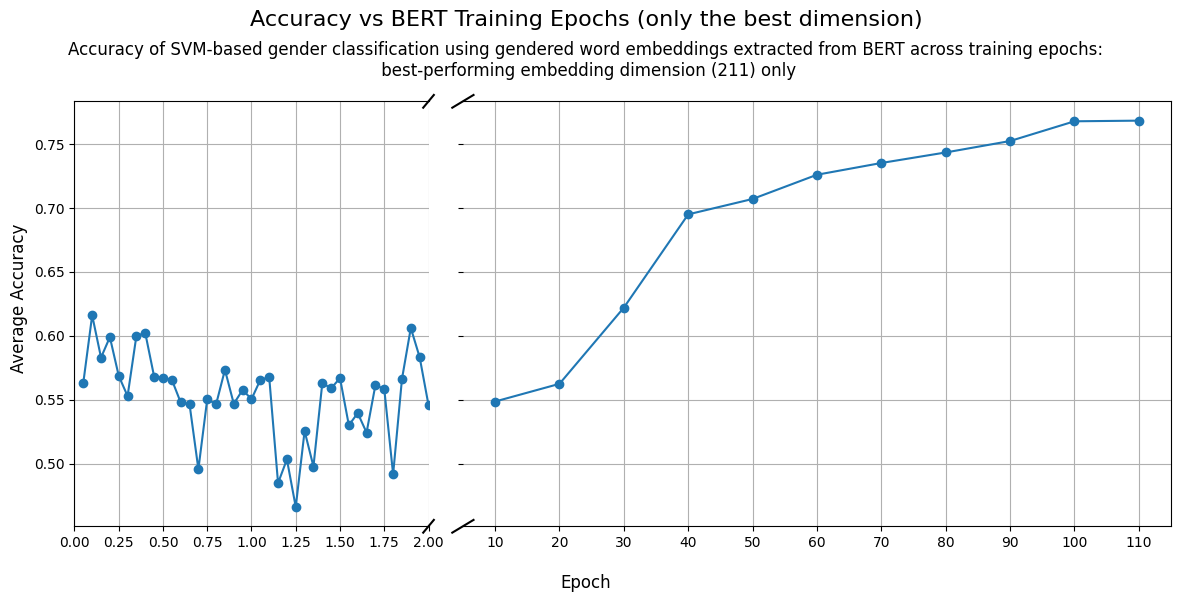

In [99]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('results_per_dimension.json', 'r') as f:
    data = json.load(f)

# Constants
steps_per_epoch = 5920
target_dim = 211

# Data holders
x_left = []     # percentage of epoch 1 (0-100%)
y_left = []

x_right = []    # epoch number (starting from 10, every 10)
y_right = []

for entry in data:
    step = entry['checkpoint']
    
    # Find dimension 211 in the dimensions list
    dim_211_data = next((d for d in entry.get('dimensions', []) if d.get('dimension') == target_dim), None)
    
    if dim_211_data:
        acc = dim_211_data['average_accuracy']
        
        if step <= 11840:  # up to 2 epochs
            percent = (step / steps_per_epoch)
            x_left.append(percent)
            y_left.append(acc)
        else:
            if step <= 651200: # up to 100 epochs
                epoch = step // steps_per_epoch
                if epoch % 10 == 0:
                    x_right.append(epoch)
                    y_right.append(acc)

# Plot with broken axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Left axis: percentage of first epoch
ax1.plot(x_left, y_left, marker='o')
ax1.grid(True)
ax1.set_xlim(0, 2)  # Slightly beyond 100%

# Right axis: full epoch numbers (every 10)
ax2.plot(x_right, y_right, marker='o')
ax2.grid(True)
ax2.set_xticks(x_right)

# Break visual
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Set titles
fig.suptitle('Accuracy vs BERT Training Epochs (only the best dimension)\n\n', fontsize=16)
fig.text(0.5, 0.87, 
         'Accuracy of SVM-based gender classification using gendered word embeddings extracted from BERT across training epochs:\n best-performing embedding dimension (211) only', 
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Accuracy')

# Diagonal cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

plt.tight_layout()
plt.show()

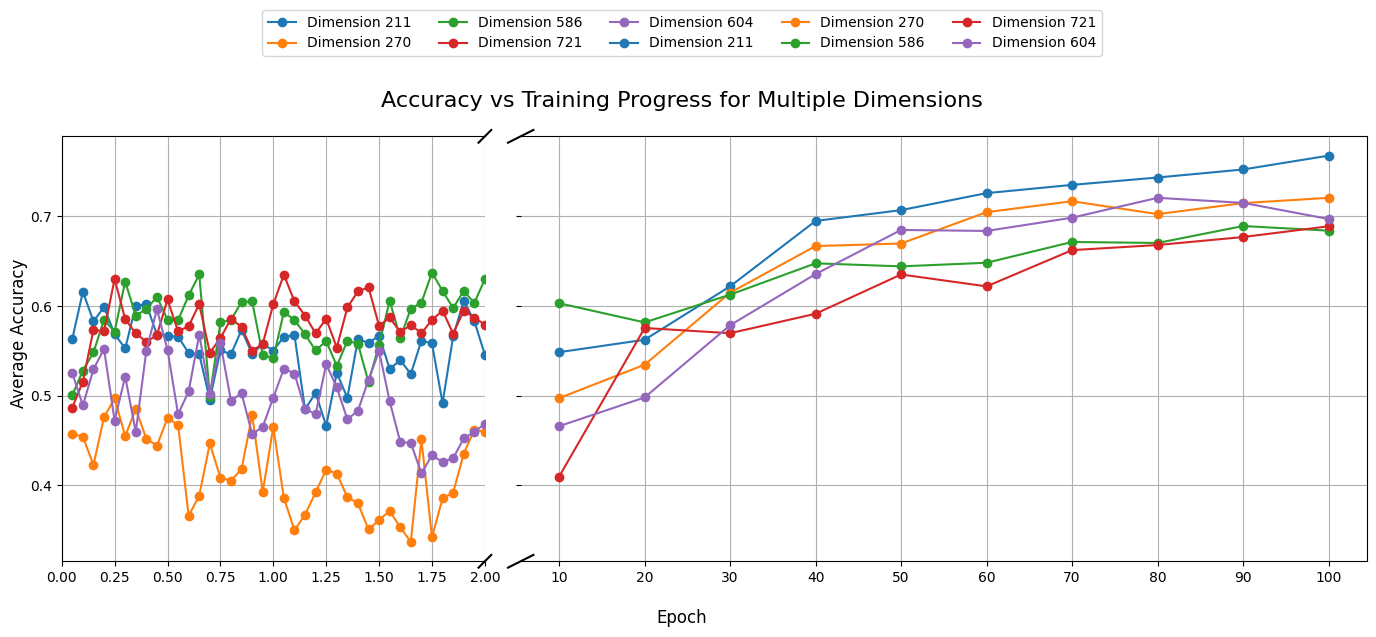

In [63]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('results_per_dimension.json', 'r') as f:
    data = json.load(f)

# Constants
steps_per_epoch = 5920
dimensions_to_plot = [211, 270, 586, 721, 604] 

# Initialize data storage: {dimension: {'x_left': [], 'y_left': [], 'x_right': [], 'y_right': []}}
dimension_data = {dim: {'x_left': [], 'y_left': [], 'x_right': [], 'y_right': []} for dim in dimensions_to_plot}

# Populate the data
for entry in data:
    step = entry['checkpoint']
    
    for dim in dimensions_to_plot:
        dim_data = next((d for d in entry.get('dimensions', []) if d.get('dimension') == dim), None)
        if dim_data:
            acc = dim_data['average_accuracy']
            if step <= 11840:  # up to 2 epochs
                percent = (step / steps_per_epoch)
                dimension_data[dim]['x_left'].append(percent)
                dimension_data[dim]['y_left'].append(acc)
            else:
                if step <= 592000: # up to 100 epochs
                    epoch = step // steps_per_epoch
                    if epoch % 10 == 0:
                        dimension_data[dim]['x_right'].append(epoch)
                        dimension_data[dim]['y_right'].append(acc)

# Plot with broken axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Plot each dimension as a separate line
for dim in dimensions_to_plot:
    label = f"Dimension {dim}"
    ax1.plot(dimension_data[dim]['x_left'], dimension_data[dim]['y_left'], marker='o', label=label)
    ax2.plot(dimension_data[dim]['x_right'], dimension_data[dim]['y_right'], marker='o', label=label)

# Axes setup
ax1.grid(True)
ax1.set_xlim(0, 2)
ax2.grid(True)

ax2.set_xticks(sorted(set(sum([dimension_data[dim]['x_right'] for dim in dimensions_to_plot], []))))

# Break visual
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Diagonal cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# Titles and labels
fig.suptitle('\n\nAccuracy vs Training Progress for Multiple Dimensions', fontsize=16)
fig.supxlabel('Epoch')
fig.supylabel('Average Accuracy')
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=len(dimensions_to_plot))

plt.tight_layout()
plt.show()


## Gender classification using each, but the best dimension

In [61]:
import os
import io
import re
import json
import numpy as np
import random
from collections import defaultdict, Counter
from azure.storage.blob import BlobServiceClient
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))

# Word-label pairs
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]
word_labels = dict(words_labels)

def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

def run_group_kfold(X, y, groups, checkpoint_id):
    gkf = GroupKFold(n_splits=5)
    fold_accuracies = []
    fold_reports = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"], output_dict=True)

        fold_accuracies.append(acc)
        fold_reports.append({
            "fold": fold_idx + 1,
            "accuracy": acc,
            "classification_report": report,
            "label_distribution": dict(Counter(y_test))
        })

    result = {
        "checkpoint": checkpoint_id,
        "average_accuracy": float(np.mean(fold_accuracies)),
        "folds": fold_reports
    }
    return result

# Discover all embedding-label pairs
blobs = container_client.list_blobs()
embedding_blobs = []
label_blobs = {}

for blob in blobs:
    if re.match(r"embeddings_checkpoint-\d+\.npy", blob.name):
        checkpoint_id = int(re.findall(r"\d+", blob.name)[0])  # Convert to int here
        embedding_blobs.append((checkpoint_id, blob.name))
    elif re.match(r"labels_checkpoint-\d+\.npy", blob.name):
        checkpoint_id = int(re.findall(r"\d+", blob.name)[0])  # And here
        label_blobs[checkpoint_id] = blob.name

# Store all results here
all_results = []
DIM_TO_REMOVE = 211

for checkpoint_id, embedding_blob in sorted(embedding_blobs):
    if checkpoint_id not in label_blobs:
        continue

    print(f"\n>>> Processing checkpoint {checkpoint_id}...")

    X_full_raw = load_npy_from_azure(embedding_blob)
    # Remove the specified dimension
    X = np.delete(X_full_raw, DIM_TO_REMOVE, axis=1)
    print(f"Removed dimension {DIM_TO_REMOVE}, new shape: {X.shape}")
    y = load_npy_from_azure(label_blobs[checkpoint_id])

    # Map word -> embedding indices
    word_to_indices = {}
    current_idx = 0
    for word, label in words_labels:
        count = 0
        start_idx = current_idx
        while current_idx < len(y) and y[current_idx] == label:
            count += 1
            current_idx += 1
        word_to_indices[word] = list(range(start_idx, start_idx + count)) if count > 0 else []

    # Flatten embeddings + labels
    X_raw, y_raw, groups_raw = [], [], []
    for word, indices in word_to_indices.items():
        for idx in indices:
            groups_raw.append(word)
            X_raw.append(X[idx])
            y_raw.append(word_labels[word])

    X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)
    result = run_group_kfold(X_full, y_full, groups, checkpoint_id)
    print(f"Average accuracy for checkpoint {checkpoint_id}: {result['average_accuracy']:.8f}")
    all_results.append(result)

def convert_keys_to_str(obj):
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str(i) for i in obj]
    else:
        return obj

# Convert before saving
clean_results = convert_keys_to_str(all_results)

# Save to JSON
with open("results_allbutone.json", "w") as f:
    json.dump(clean_results, f, indent=2)

print("\nAll checkpoint evaluations complete. Results saved to 'results_allbutone.json'.")


>>> Processing checkpoint 296...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 296: 0.49113608

>>> Processing checkpoint 592...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 592: 0.48080493

>>> Processing checkpoint 888...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 888: 0.50929317

>>> Processing checkpoint 1184...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 1184: 0.50070807

>>> Processing checkpoint 1480...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 1480: 0.48784711

>>> Processing checkpoint 1776...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 1776: 0.48435260

>>> Processing checkpoint 2072...
Removed dimension 211, new shape: (117652, 767)
Average accuracy for checkpoint 2072: 0.49780148

>>> Processing checkpoint 2368...
Removed dimension 211, new shape: (117652, 767)

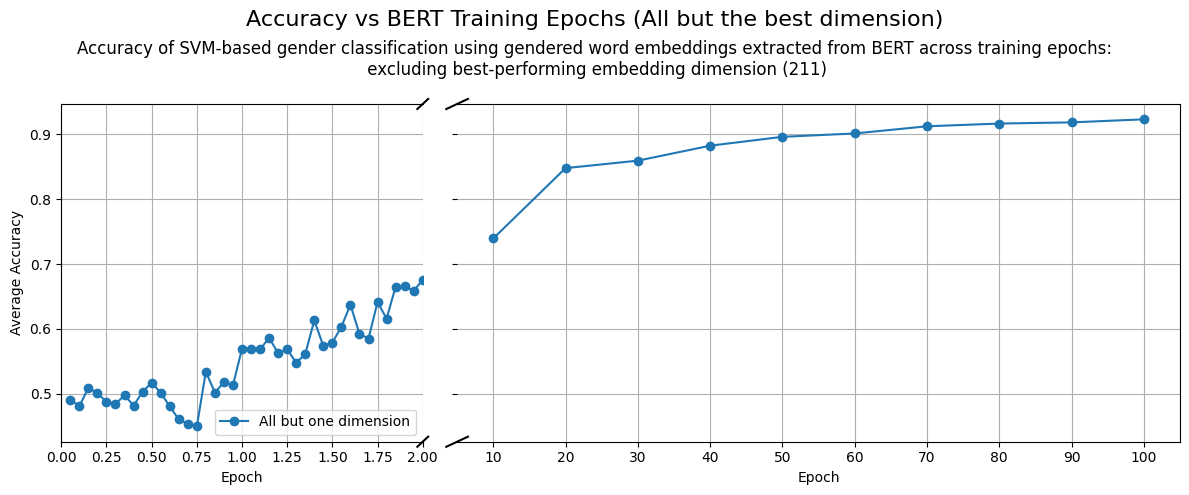

In [92]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('results_allbutone.json', 'r') as f:
    data = json.load(f)

steps_per_epoch = 5920
x_left, y_left = [], []
x_right, y_right = [], []

# Fill in the data
for entry in data:
    step = entry['checkpoint']
    acc = entry['average_accuracy']
    
    if step <= 11840:  # up to 2 epochs
        percent = step / steps_per_epoch
        x_left.append(percent)
        y_left.append(acc)
    elif step <= 592000:  # up to 100 epochs
        epoch = step // steps_per_epoch
        if epoch % 10 == 0:
            x_right.append(epoch)
            y_right.append(acc)

# Set up broken axis plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                               gridspec_kw={'width_ratios': [1, 2]})

# Only label one side to avoid duplicate legend
ax1.plot(x_left, y_left, marker='o', label="All but one dimension")
ax2.plot(x_right, y_right, marker='o')

# Set x-limits
ax1.set_xlim(0, 2)
ax2.set_xlim(min(x_right) - 5, max(x_right) + 5)

# Axes style
ax1.grid(True)
ax2.grid(True)
ax2.set_xticks(sorted(set(x_right)))

# Hide the spines and sync axis ticks
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Diagonal break marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# Set labels
fig.suptitle('Accuracy vs BERT Training Epochs (All but the best dimension)\n', fontsize=16)
fig.text(0.5, 0.85, 
         'Accuracy of SVM-based gender classification using gendered word embeddings extracted from BERT across training epochs:\n excluding best-performing embedding dimension (211)', 
         ha='center', fontsize=12)
ax1.set_xlabel("Epoch")
ax2.set_xlabel("Epoch")
ax1.set_ylabel("Average Accuracy")

# Single legend
ax1.legend(loc='lower right')

# Adjust layout to fit title and avoid overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


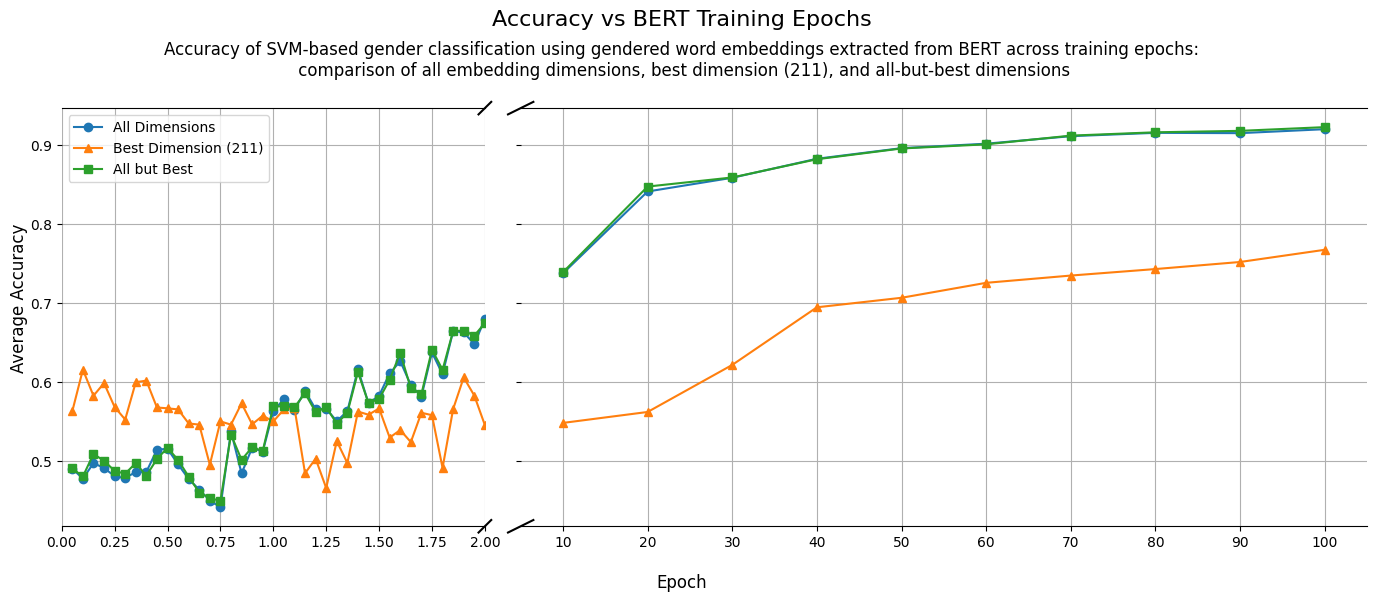

In [91]:
import json
import matplotlib.pyplot as plt

# Constants
steps_per_epoch = 5920

def load_data(file_path, key=None):
    with open(file_path, 'r') as f:
        data = json.load(f)
    x_left, y_left, x_right, y_right = [], [], [], []
    for entry in data:
        step = entry['checkpoint']
        if key:
            dim_data = next((d for d in entry.get('dimensions', []) if d.get('dimension') == key), None)
            if not dim_data:
                continue
            acc = dim_data['average_accuracy']
        else:
            acc = entry['average_accuracy']
        if step <= 11840:
            percent = step / steps_per_epoch
            x_left.append(percent)
            y_left.append(acc)
        elif step <= 592000:
            epoch = step // steps_per_epoch
            if epoch % 10 == 0:
                x_right.append(epoch)
                y_right.append(acc)
    return x_left, y_left, x_right, y_right

# Load all datasets
x1_l, y1_l, x1_r, y1_r = load_data('results_gender_classification.json')
x2_l, y2_l, x2_r, y2_r = load_data('results_per_dimension.json', key=211)
x3_l, y3_l, x3_r, y3_r = load_data('results_allbutone.json')

# Set up broken axis plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Left plot: percentage of first two epochs
ax1.plot(x1_l, y1_l, marker='o', label='All Dimensions')
ax1.plot(x2_l, y2_l, marker='^', label='Best Dimension (211)')
ax1.plot(x3_l, y3_l, marker='s', label='All but Best')
ax1.set_xlim(0, 2)
ax1.set_yticks([i / 10 for i in range(5, 11)])
ax1.grid(True)

# Right plot: full epochs
ax2.plot(x1_r, y1_r, marker='o')
ax2.plot(x2_r, y2_r, marker='^')
ax2.plot(x3_r, y3_r, marker='s')
ax2.set_xticks(sorted(set(x1_r + x2_r + x3_r)))
ax2.set_xlim(min(x1_r + x2_r + x3_r) - 5, max(x1_r + x2_r + x3_r) + 5)
ax2.grid(True)

# Axis visual breaks
for ax in (ax1, ax2):
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    if ax == ax1:
        ax.tick_params(labelright=False)
    else:
        ax.tick_params(labelright=False, labelleft=False)

d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)
kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

# Labels and title
fig.suptitle('Accuracy vs BERT Training Epochs\n', fontsize=16)
fig.text(0.5, 0.87, 
         'Accuracy of SVM-based gender classification using gendered word embeddings extracted from BERT across training epochs:\n comparison of all embedding dimensions, best dimension (211), and all-but-best dimensions', 
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Accuracy')
ax1.legend(loc='upper left')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
